# 03 - Walk-Forward Day-Ahead Forecasting (per-Tag parallel)

**Lineup (alle Standorte identisch):**
- Point (Benchmark): Persistence, ARIMA(1,0,0), Elastic Net
- Probabilistisch (Hauptbeitrag): XGBoost Quantile, QGB, QRF -- je 5 Quantile (q10-q90)

Parallelisierung ueber Prognosetage (joblib/loky). SHAP pro Tree-Modell pro Standort als .pkl.

**Stepwise:** erst 1 Monat, dann 3 Monate, dann voll (2017-2025). Steuerung via Config-Zelle.

In [1]:
from __future__ import annotations
import warnings, sys, pickle, os
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.gate_close_features import engineer_gate_close_features

DATA_PATH    = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
NWP_DIR      = PROJECT_ROOT / "data" / "raw" / "nwp"
RESULTS_DIR  = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
TABLES_DIR   = RESULTS_DIR / "tables"
FIGURES_DIR  = RESULTS_DIR / "figures"
SHAP_DIR     = RESULTS_DIR / "shap_explanations"
for d in [FORECAST_DIR, TABLES_DIR, FIGURES_DIR, SHAP_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print("Setup OK")

Setup OK


## Config (Stepwise steuern)

In [2]:
# ===== STEPWISE CONFIG =====
# Schritt 1: 1 Monat, 1 Standort  ->  Schritt 2: 3 Monate  ->  Schritt 3: voll, alle 4
SELECTED_PLANTS   = ["Schonungen", "Schwanfeld", "Trabelsdorf", "Obbach"]
TEST_START        = "2017-02-01"
TEST_END          = "2025-08-31"              # Volllauf
TRAIN_WINDOW_DAYS = 30
QUANTILES         = [0.1, 0.25, 0.5, 0.75, 0.9]
N_JOBS            = -1                          # alle Cores (loky)
TARGET            = "energy_mwh"

print("Plants:", SELECTED_PLANTS)
print("Test:", TEST_START, "->", TEST_END)
print("Quantiles:", QUANTILES)

Plants: ['Schonungen', 'Schwanfeld', 'Trabelsdorf', 'Obbach']
Test: 2017-02-01 -> 2025-08-31
Quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]


## 1. Daten + 3-Layer-Features (alle Standorte, Filter via SELECTED_PLANTS)

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values(["site", "timestamp"]).reset_index(drop=True)
if "energy_mwh" not in df.columns:
    df["energy_mwh"] = df["power"] / 1000

df = engineer_gate_close_features(df, lookback_days=8)

dfs_nwp = {}
for site in df["site"].unique():
    p = NWP_DIR / f"nwp_{site.lower()}.csv"
    if p.exists():
        dfs_nwp[site] = pd.read_csv(p, parse_dates=["timestamp"])

merged = []
for site in sorted(df["site"].unique()):
    ds = df[df["site"] == site].copy()
    if site in dfs_nwp:
        ds = pd.merge(ds, dfs_nwp[site], on="timestamp", how="left")
    merged.append(ds)
df = pd.concat(merged, ignore_index=True).sort_values(["site", "timestamp"]).reset_index(drop=True)

TIME_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
GATE_CLOSE_FEATURES = ["energy_at_gate", "energy_gate_m12h", "energy_gate_m24h", "energy_gate_m48h", "energy_gate_m168h",
    "energy_roll24_at_gate", "energy_roll_std24_at_gate", "energy_roll168_at_gate", "energy_roll_std168_at_gate",
    "wind_at_gate", "wind_gate_m12h", "wind_gate_m24h", "wind_gate_m168h",
    "wind_roll24_at_gate", "wind_roll_std24_at_gate", "wind_roll168_at_gate", "wind_roll_std168_at_gate"]
NWP_FEATURES = ["nwp_ws100", "nwp_wd100", "nwp_temp2m", "nwp_cloud_cover"]
FEATURES = [f for f in (TIME_FEATURES + GATE_CLOSE_FEATURES + NWP_FEATURES) if f in df.columns]

print("Data:", df.shape, "| Sites:", sorted(df["site"].unique()))
print("Features:", len(FEATURES))

Data: (262827, 37) | Sites: ['Obbach', 'Schonungen', 'Schwanfeld', 'Trabelsdorf']
Features: 25


## 2. Worker: simulate_day (self-contained, loky-safe)

In [4]:
def simulate_day(args):
    """Self-contained Worker fuer EINEN Prognosetag (loky-safe).
    args = (site, X_train, y_train, X_val, y_val, ts_val, QUANTILES)
    Returns (pred_df, shap_dict) oder None.
    """
    import os
    os.environ["OMP_NUM_THREADS"] = "1"
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import ElasticNet
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    import xgboost as xgb
    from statsmodels.tsa.arima.model import ARIMA
    import shap

    site, X_train, y_train, X_val, y_val, ts_val, QUANTILES = args
    n = len(X_val)
    if len(X_train) < 24 or n == 0:
        return None

    point = {}
    quant = {}   # {model: {q: array}}
    shp = {}     # {model: shap_array (q50)}

    # === POINT (Benchmark) ===
    point["persistence"] = np.full(n, y_train[-1])
    try:
        am = ARIMA(y_train, order=(1, 0, 0)).fit()
        point["arima"] = np.clip(am.get_forecast(steps=n).predicted_mean.values, 0, None)
    except Exception:
        point["arima"] = point["persistence"]
    try:
        en = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42).fit(X_train, y_train)
        point["elastic_net"] = np.clip(en.predict(X_val), 0, None)
    except Exception:
        point["elastic_net"] = point["persistence"]

    # === XGBoost Quantile (pro Quantil ein Modell) ===
    quant["xgb"] = {}
    xgb_med = None
    for q in QUANTILES:
        m = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                             objective="reg:quantileerror", quantile_alpha=q,
                             tree_method="hist", n_jobs=1, random_state=42, verbosity=0)
        m.fit(X_train, y_train)
        quant["xgb"][q] = np.clip(m.predict(X_val), 0, None)
        if abs(q - 0.5) < 1e-9:
            xgb_med = m

    # === QGB (Gradient Boosting Quantile) ===
    quant["qgb"] = {}
    qgb_med = None
    for q in QUANTILES:
        m = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05,
                                      loss="quantile", alpha=q, subsample=0.8, random_state=42)
        m.fit(X_train, y_train)
        quant["qgb"][q] = np.clip(m.predict(X_val), 0, None)
        if abs(q - 0.5) < 1e-9:
            qgb_med = m

    # === QRF (ein Forest, Quantile aus Einzelbaeumen) ===
    qrf = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=5,
                                n_jobs=1, random_state=42).fit(X_train, y_train)
    tree_preds = np.stack([t.predict(X_val) for t in qrf.estimators_], axis=0)
    quant["qrf"] = {}
    for q in QUANTILES:
        quant["qrf"][q] = np.clip(np.percentile(tree_preds, q * 100, axis=0), 0, None)

    # Monotonie erzwingen (kein Quantile-Crossing)
    for mdl in quant:
        arr = np.sort(np.stack([quant[mdl][q] for q in QUANTILES], axis=1), axis=1)
        for j, q in enumerate(QUANTILES):
            quant[mdl][q] = arr[:, j]

    # === SHAP (q50-Modelle der 3 Tree-Modelle) ===
    for name, model in [("xgb", xgb_med), ("qgb", qgb_med), ("qrf", qrf)]:
        try:
            shp[name] = shap.TreeExplainer(model).shap_values(X_val)
        except Exception:
            shp[name] = None

    # === Prediction-DataFrame fuer diesen Tag ===
    row = {"site": site, "timestamp": ts_val, "y_true": y_val}
    for pname, arr in point.items():
        row[pname] = arr
    for mdl in ["xgb", "qgb", "qrf"]:
        for q in QUANTILES:
            row[f"{mdl}_q{int(q * 100):02d}"] = quant[mdl][q]
    pred_df = pd.DataFrame(row)

    return pred_df, shp

## 3. Day-Args Builder

In [5]:
def build_day_args(plant, dfp, FEATURES, TARGET, QUANTILES, train_days, test_start, test_end):
    dfp = dfp.sort_values("timestamp").dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
    if len(dfp) == 0:
        return []
    X = dfp[FEATURES].values
    y = dfp[TARGET].values
    tsv = dfp["timestamp"].values
    days = pd.date_range(test_start, test_end, freq="D")
    args = []
    for d in days:
        d0 = np.datetime64(pd.Timestamp(d))
        d1 = d0 + np.timedelta64(24, "h")
        tr0 = d0 - np.timedelta64(int(train_days), "D")
        tr = (tsv >= tr0) & (tsv < d0)
        va = (tsv >= d0) & (tsv < d1)
        if tr.sum() < 24 or va.sum() == 0:
            continue
        args.append((plant, X[tr], y[tr], X[va], y[va], tsv[va], QUANTILES))
    return args

print("build_day_args ready")

build_day_args ready


## 4. Parallel-Simulation pro Standort + Speichern (Predictions + SHAP)

In [6]:
import time
all_predictions = {}

for plant in SELECTED_PLANTS:
    t0 = time.time()
    dfp = df[df["site"] == plant].copy()
    args = build_day_args(plant, dfp, FEATURES, TARGET, QUANTILES, TRAIN_WINDOW_DAYS, TEST_START, TEST_END)
    print(f"{plant}: {len(args)} Tage -> simuliere (n_jobs={N_JOBS}) ...")

    results = Parallel(n_jobs=N_JOBS, backend="loky")(delayed(simulate_day)(a) for a in args)
    results = [r for r in results if r is not None]

    predictions = pd.concat([r[0] for r in results], ignore_index=True)
    out_csv = FORECAST_DIR / f"predictions_{plant.lower()}.csv"
    predictions.to_csv(out_csv, index=False)

    for mdl in ["xgb", "qgb", "qrf"]:
        pool = [r[1][mdl] for r in results if r[1].get(mdl) is not None]
        if pool:
            shap_arr = np.concatenate(pool, axis=0)
            with open(SHAP_DIR / f"shap_{mdl}_{plant.lower()}.pkl", "wb") as f:
                pickle.dump({"shap_values": shap_arr, "feature_names": FEATURES}, f)

    all_predictions[plant] = predictions
    print(f"  {plant}: {len(predictions)} rows, {time.time()-t0:.0f}s -> {out_csv.name}")

print("Simulation done.")

Schonungen: 3110 Tage -> simuliere (n_jobs=-1) ...


  Schonungen: 74289 rows, 555s -> predictions_schonungen.csv


Schwanfeld: 3125 Tage -> simuliere (n_jobs=-1) ...


  Schwanfeld: 74910 rows, 555s -> predictions_schwanfeld.csv


Trabelsdorf: 3054 Tage -> simuliere (n_jobs=-1) ...


  Trabelsdorf: 73223 rows, 563s -> predictions_trabelsdorf.csv


Obbach: 365 Tage -> simuliere (n_jobs=-1) ...


  Obbach: 8736 rows, 69s -> predictions_obbach.csv
Simulation done.


## 5. ARIMA / Elastic Net Gate (Verbesserung ueber Persistence?)

In [7]:
from sklearn.metrics import mean_absolute_error
print("=== Point-Benchmark MAE (vs Persistence) ===")
for plant, pred in all_predictions.items():
    y = pred["y_true"].values
    mae_p = mean_absolute_error(y, pred["persistence"].values)
    print(f"{plant}:")
    for m in ["persistence", "arima", "elastic_net"]:
        if m in pred.columns:
            mae = mean_absolute_error(y, pred[m].values)
            impr = 100 * (mae_p - mae) / mae_p if mae_p > 0 else 0.0
            print(f"  {m:<14} MAE={mae:.4f}  ({impr:+.1f}% vs persistence)")
print()
print("Hinweis: <~2% Verbesserung -> ARIMA/EN nur im Grundlagenkapitel, raus aus Vollsim.")

=== Point-Benchmark MAE (vs Persistence) ===
Schonungen:
  persistence    MAE=0.3155  (+0.0% vs persistence)
  arima          MAE=0.3155  (+0.0% vs persistence)
  elastic_net    MAE=0.1949  (+38.2% vs persistence)
Schwanfeld:
  persistence    MAE=0.5320  (+0.0% vs persistence)
  arima          MAE=0.5320  (+0.0% vs persistence)
  elastic_net    MAE=0.3798  (+28.6% vs persistence)
Trabelsdorf:
  persistence    MAE=0.4950  (+0.0% vs persistence)
  arima          MAE=0.4950  (+0.0% vs persistence)
  elastic_net    MAE=0.3128  (+36.8% vs persistence)
Obbach:
  persistence    MAE=0.5431  (+0.0% vs persistence)
  arima          MAE=0.5431  (+0.0% vs persistence)
  elastic_net    MAE=0.3563  (+34.4% vs persistence)

Hinweis: <~2% Verbesserung -> ARIMA/EN nur im Grundlagenkapitel, raus aus Vollsim.


## 6. Pinball Loss (alle Quantile + Modelle)

In [8]:
def pinball(y, yp, q):
    e = y - yp
    return np.mean(np.maximum(q * e, (q - 1) * e))

PROB = ["xgb", "qgb", "qrf"]
rows = []
for plant, pred in all_predictions.items():
    y = pred["y_true"].values
    for mdl in PROB:
        for q in QUANTILES:
            col = f"{mdl}_q{int(q*100):02d}"
            if col in pred.columns:
                rows.append({"plant": plant, "model": mdl, "quantile": q,
                             "pinball_loss": float(pinball(y, pred[col].values, q))})
pinball_df = pd.DataFrame(rows)
pinball_df.to_csv(TABLES_DIR / "pinball_evaluation.csv", index=False)
print("Mean Pinball je Modell (CRPS-Proxy):")
print(pinball_df.groupby("model")["pinball_loss"].mean().round(4))

Mean Pinball je Modell (CRPS-Proxy):
model
qgb    0.0987
qrf    0.1022
xgb    0.1006
Name: pinball_loss, dtype: float64


## 7. Viz A: Forecast vs. Actual (Beispielmonat, stuendlich)

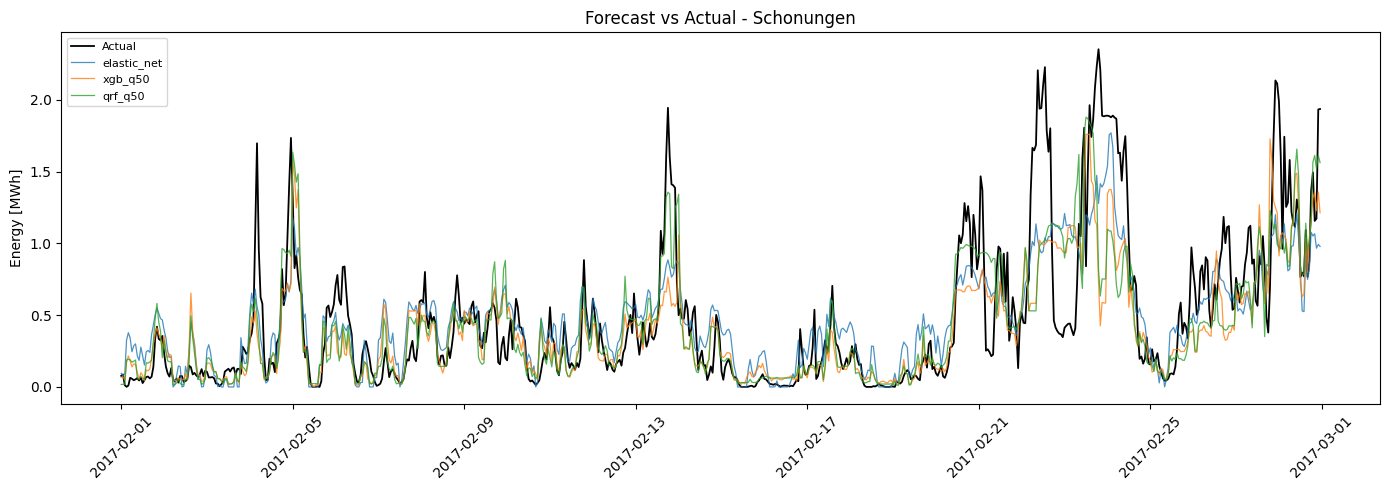

In [9]:
PLOT_PLANT = SELECTED_PLANTS[0]
pred = all_predictions[PLOT_PLANT].sort_values("timestamp").reset_index(drop=True)
m = pred.iloc[:28*24]   # erste ~4 Wochen
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(m["timestamp"], m["y_true"], color="black", lw=1.3, label="Actual")
for col, c in [("elastic_net", "#1f77b4"), ("xgb_q50", "#d62728"), ("qrf_q50", "#2ca02c")]:
    if col in m.columns:
        ax.plot(m["timestamp"], m[col], lw=0.9, alpha=0.8, label=col)
ax.set_title(f"Forecast vs Actual - {PLOT_PLANT}")
ax.set_ylabel("Energy [MWh]"); ax.legend(fontsize=8); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"forecast_vs_actual_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 8. Viz B: Quantil-Baender (q10-q90)

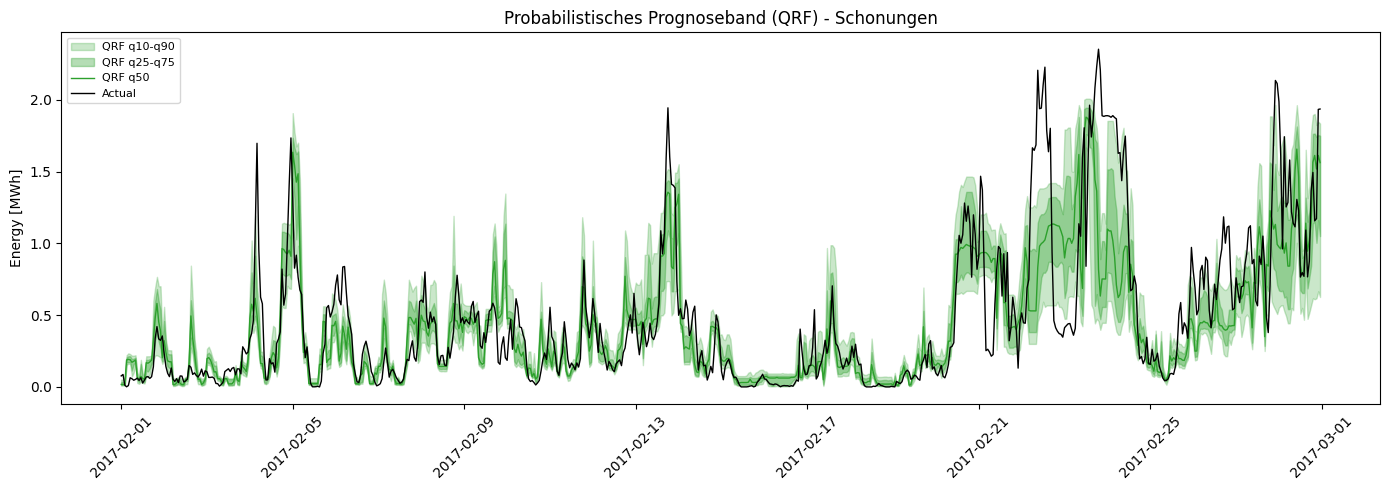

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(m["timestamp"], m["qrf_q10"], m["qrf_q90"], alpha=0.25, color="#2ca02c", label="QRF q10-q90")
ax.fill_between(m["timestamp"], m["qrf_q25"], m["qrf_q75"], alpha=0.35, color="#2ca02c", label="QRF q25-q75")
ax.plot(m["timestamp"], m["qrf_q50"], color="#2ca02c", lw=1.0, label="QRF q50")
ax.plot(m["timestamp"], m["y_true"], color="black", lw=1.0, label="Actual")
ax.set_title(f"Probabilistisches Prognoseband (QRF) - {PLOT_PLANT}")
ax.set_ylabel("Energy [MWh]"); ax.legend(fontsize=8); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"quantile_band_qrf_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 9. Viz C: Pinball Loss ueber Quantile + Modelle

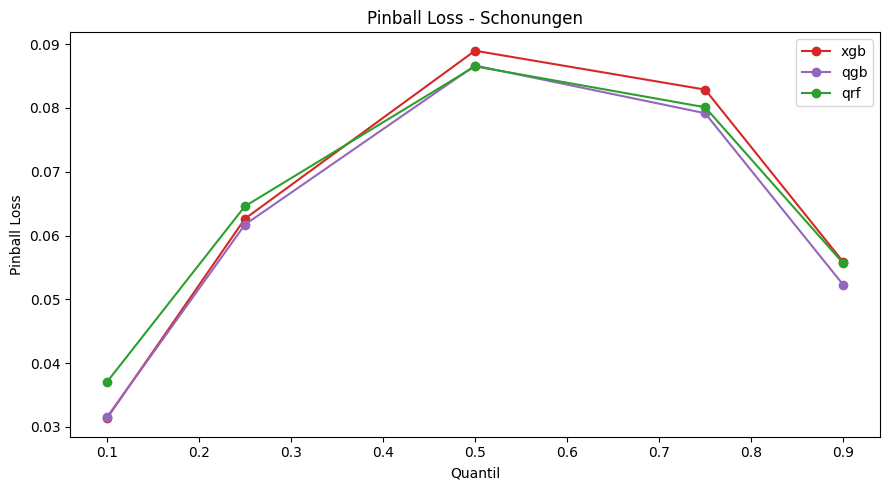

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sub = pinball_df[pinball_df["plant"] == PLOT_PLANT]
for mdl, c in [("xgb", "#d62728"), ("qgb", "#9467bd"), ("qrf", "#2ca02c")]:
    s = sub[sub["model"] == mdl].sort_values("quantile")
    if len(s):
        ax.plot(s["quantile"], s["pinball_loss"], marker="o", label=mdl, color=c)
ax.set_xlabel("Quantil"); ax.set_ylabel("Pinball Loss"); ax.set_title(f"Pinball Loss - {PLOT_PLANT}")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"pinball_loss_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 10. Viz D: Scatter Actual vs. Predicted (pro Modell)

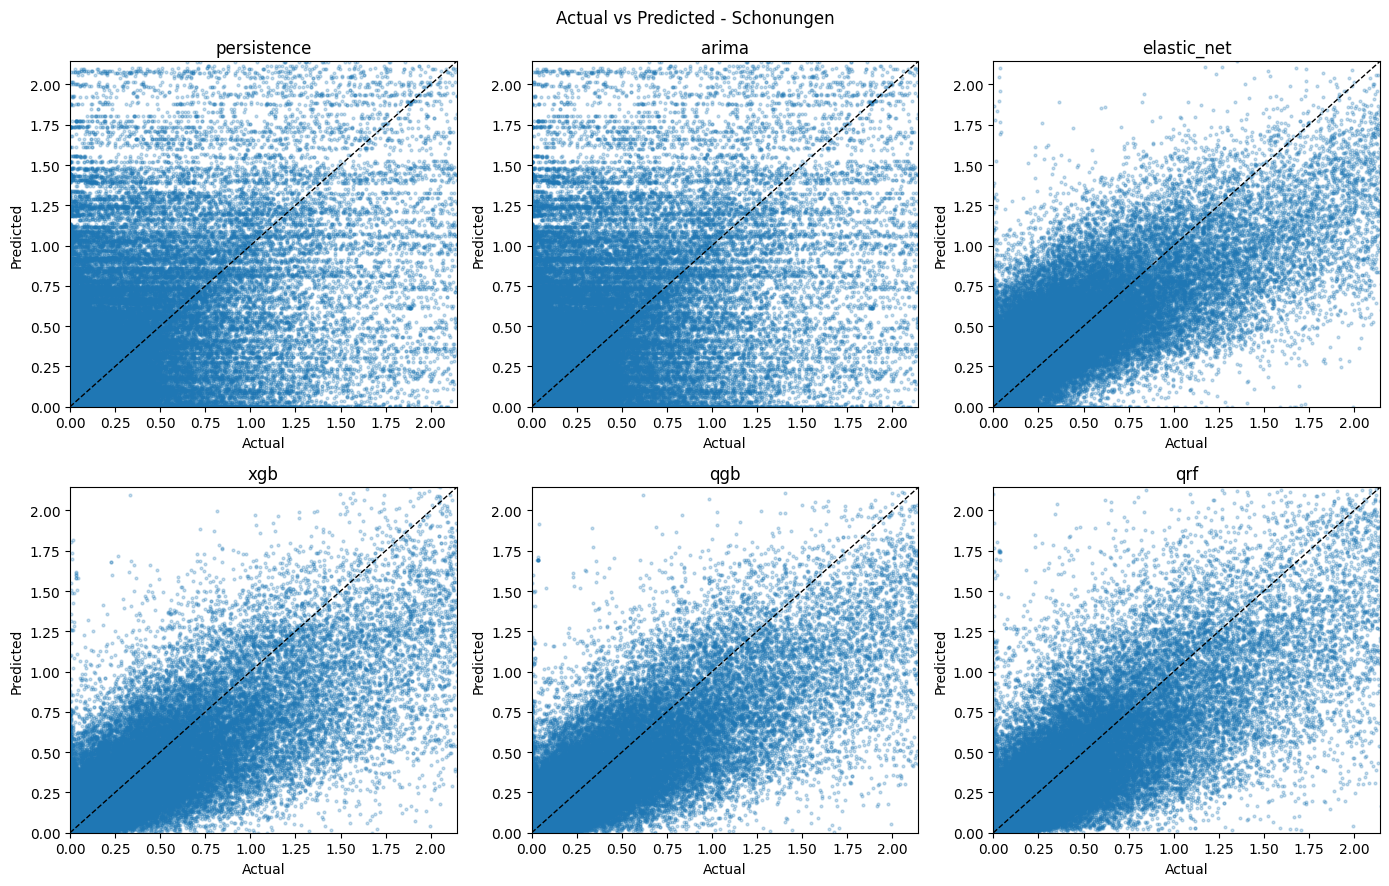

In [12]:
scatter_models = [("persistence","persistence"),("arima","arima"),("elastic_net","elastic_net"),
                  ("xgb_q50","xgb"),("qgb_q50","qgb"),("qrf_q50","qrf")]
scatter_models = [(c, n) for c, n in scatter_models if c in pred.columns]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
y = pred["y_true"].values
lim = max(1e-6, float(np.nanpercentile(y, 99)))
for ax, (col, name) in zip(axes.ravel(), scatter_models):
    yp = pred[col].values
    ax.scatter(y, yp, s=4, alpha=0.25, color="#1f77b4")
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(name); ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
for ax in axes.ravel()[len(scatter_models):]:
    ax.axis("off")
plt.suptitle(f"Actual vs Predicted - {PLOT_PLANT}"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"scatter_actual_pred_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()